# Task 2: Integrated Mutation and Methylation Classification
## Overview
This script integrates mutation and methylation data to build a classifier for cancer subtypes.
It includes:
- Data loading for mutation and methylation datasets
- Feature engineering for mutations and methylation
- Integration of features
- Model training with RandomForest and XGBoost
- Evaluation with metrics and confusion matrix
- Visualizations for mutation and methylation distributions

In [3]:
# Install required libraries
!pip install pandas numpy scikit-learn xgboost cudf-cu12 matplotlib --extra-index-url=https://pypi.nvidia.com

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import f1_score, precision_score, recall_score, ConfusionMatrixDisplay
import xgboost as xgb
from xgboost import XGBClassifier, DMatrix
import cudf
import os
import torch

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. Please enable GPU runtime in Colab (Runtime > Change runtime type > GPU).")
    raise SystemExit

# Set working directory
os.chdir('/content/work')

# Generate and Save Confusion Matrix
os.makedirs('out', exist_ok=True)

output_dir = 'out'
os.makedirs(output_dir, exist_ok=True)

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
GPU is available: Tesla T4


## Phase 1: Data Loading
Loads mutation, methylation, and feature data using GPU-accelerated CSV reading.
Checks for missing values and validates data integrity.

In [4]:
print("Loading data for Task 2...")
try:
    train_muts = cudf.read_csv('train_muts_data.csv').to_pandas()
    test_muts = cudf.read_csv('test_muts_data.csv').to_pandas()
    train_feats = cudf.read_csv('train_feats.csv').to_pandas()
    test_feats = cudf.read_csv('test_feats.csv').to_pandas()
    train_meth = cudf.read_csv('train_meth_data.csv').to_pandas()
    test_meth = cudf.read_csv('test_meth_data.csv').to_pandas()
    genes_100 = cudf.read_csv('100_genes.csv').to_pandas()
except FileNotFoundError as e:
    print(f"Error: File not found: {e}")
    raise SystemExit

# Check for missing values
print("Checking for missing values...")
for df, name in [(train_muts, 'train_muts'), (test_muts, 'test_muts'), (train_feats, 'train_feats'),
                 (test_feats, 'test_feats'), (train_meth, 'train_meth'), (test_meth, 'test_meth')]:
    print(f"{name}: {df.isnull().sum().sum()} missing values")


Loading data for Task 2...
Checking for missing values...
train_muts: 0 missing values
test_muts: 0 missing values
train_feats: 0 missing values
test_feats: 0 missing values
train_meth: 0 missing values
test_meth: 0 missing values


## Phase 2: Feature Engineering (Mutations)
Generates mutation features:
- Total mutations per patient
- Mutations by variant classification
- Gene-specific mutations
- Mutation types (Transition, Transversion, etc.)
- Normalized mutation rates

In [5]:
print("Creating mutation features...")
train_total_muts = train_muts.groupby('case_id').size().reset_index(name='Total_Mutations')
test_total_muts = test_muts.groupby('case_id').size().reset_index(name='Total_Mutations')
train_var_counts = train_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
train_var_counts.columns = [f'Mutations_{col}' for col in train_var_counts.columns]
test_var_counts = test_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
test_var_counts.columns = [f'Mutations_{col}' for col in test_var_counts.columns]
train_gene_var = train_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
train_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in train_gene_var.columns]
test_gene_var = test_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
test_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in test_gene_var.columns]

def classify_mutation(row):
    ref, tumor = row['Reference_Allele'], row['Tumor_Seq_Allele1']
    if len(ref) == len(tumor) == 1:
        transitions = {('A', 'G'), ('G', 'A'), ('C', 'T'), ('T', 'C')}
        return 'Transition' if (ref, tumor) in transitions else 'Transversion'
    elif len(ref) > len(tumor):
        return 'Deletion'
    elif len(ref) < len(tumor):
        return 'Insertion'
    return 'Other'

train_muts['Mut_Type'] = train_muts.apply(classify_mutation, axis=1)
test_muts['Mut_Type'] = test_muts.apply(classify_mutation, axis=1)
train_mut_types = train_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
train_mut_types.columns = [f'Mutations_{col}' for col in train_mut_types.columns]
test_mut_types = test_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
test_mut_types.columns = [f'Mutations_{col}' for col in test_mut_types.columns]

genes_100['Length'] = genes_100['Sequence'].str.len()
train_norm_muts = train_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
train_norm_muts = train_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
train_norm_muts['Norm_Mutations'] = train_norm_muts['Count'] / train_norm_muts['Length']
train_norm_muts = train_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
train_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in train_norm_muts.columns]
test_norm_muts = test_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
test_norm_muts = test_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
test_norm_muts['Norm_Mutations'] = test_norm_muts['Count'] / test_norm_muts['Length']
test_norm_muts = test_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
test_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in test_norm_muts.columns]

train_features = train_total_muts.set_index('case_id').join([train_var_counts, train_gene_var, train_mut_types, train_norm_muts]).reset_index()
test_features = test_total_muts.set_index('case_id').join([test_var_counts, test_gene_var, test_mut_types, test_norm_muts]).reset_index()

Creating mutation features...


## Phase 3: Feature Engineering (Methylation)
Generates methylation features:
- Average methylation per gene
- Standard deviation of methylation
- Proportion of hypermethylated sites (beta_val > 0.7)
- Mutation-methylation interaction

In [6]:
print("Creating methylation features...")
train_meth_avg = train_meth.groupby(['case_id', 'matching_genes'])['beta_val'].mean().unstack(fill_value=0)
train_meth_avg.columns = [f'Meth_Avg_{col}' for col in train_meth_avg.columns]
test_meth_avg = test_meth.groupby(['case_id', 'matching_genes'])['beta_val'].mean().unstack(fill_value=0)
test_meth_avg.columns = [f'Meth_Avg_{col}' for col in test_meth_avg.columns]
train_meth_std = train_meth.groupby(['case_id', 'matching_genes'])['beta_val'].std().unstack(fill_value=0)
train_meth_std.columns = [f'Meth_Std_{col}' for col in train_meth_std.columns]
test_meth_std = test_meth.groupby(['case_id', 'matching_genes'])['beta_val'].std().unstack(fill_value=0)
test_meth_std.columns = [f'Meth_Std_{col}' for col in test_meth_std.columns]
train_meth_high = train_meth[train_meth['beta_val'] > 0.7].groupby(['case_id', 'matching_genes']).size().unstack(fill_value=0)
train_meth_high = train_meth_high.div(train_meth.groupby(['case_id', 'matching_genes']).size().unstack(fill_value=1)).fillna(0)
train_meth_high.columns = [f'Meth_High_Prop_{col}' for col in train_meth_high.columns]
test_meth_high = test_meth[test_meth['beta_val'] > 0.7].groupby(['case_id', 'matching_genes']).size().unstack(fill_value=0)
test_meth_high = test_meth_high.div(test_meth.groupby(['case_id', 'matching_genes']).size().unstack(fill_value=1)).fillna(0)
test_meth_high.columns = [f'Meth_High_Prop_{col}' for col in test_meth_high.columns]
train_interaction = train_muts.merge(train_meth[train_meth['beta_val'] > 0.7], left_on=['case_id', 'Gene_name'], right_on=['case_id', 'matching_genes'], how='inner')
train_interaction = train_interaction.groupby('case_id').size().reset_index(name='Mut_Meth_Interaction')
test_interaction = test_muts.merge(test_meth[test_meth['beta_val'] > 0.7], left_on=['case_id', 'Gene_name'], right_on=['case_id', 'matching_genes'], how='inner')
test_interaction = test_interaction.groupby('case_id').size().reset_index(name='Mut_Meth_Interaction')
train_interaction = train_interaction.set_index('case_id').reindex(train_features['case_id']).fillna(0).reset_index()
test_interaction = test_interaction.set_index('case_id').reindex(test_features['case_id']).fillna(0).reset_index()

# Combine features
train_combined = train_features.set_index('case_id').join([train_meth_avg, train_meth_std, train_meth_high, train_interaction.set_index('case_id')]).reset_index()
test_combined = test_features.set_index('case_id').join([test_meth_avg, test_meth_std, test_meth_high, test_interaction.set_index('case_id')]).reset_index()
train_combined.to_csv('out/train_combined.csv', index=False)
test_combined.to_csv('out/test_combined.csv', index=False)
print("Combined features saved as 'train_combined.csv' and 'test_combined.csv'.")

Creating methylation features...
Combined features saved as 'train_combined.csv' and 'test_combined.csv'.


## Phase 4: Visualizations
Creates visualizations for:
- Mutation distribution by variant type (train + test)
- Top 20 genes by mutation count (train + test)
- Methylation distribution by gene (train only)

Creating visualizations for Task 2...


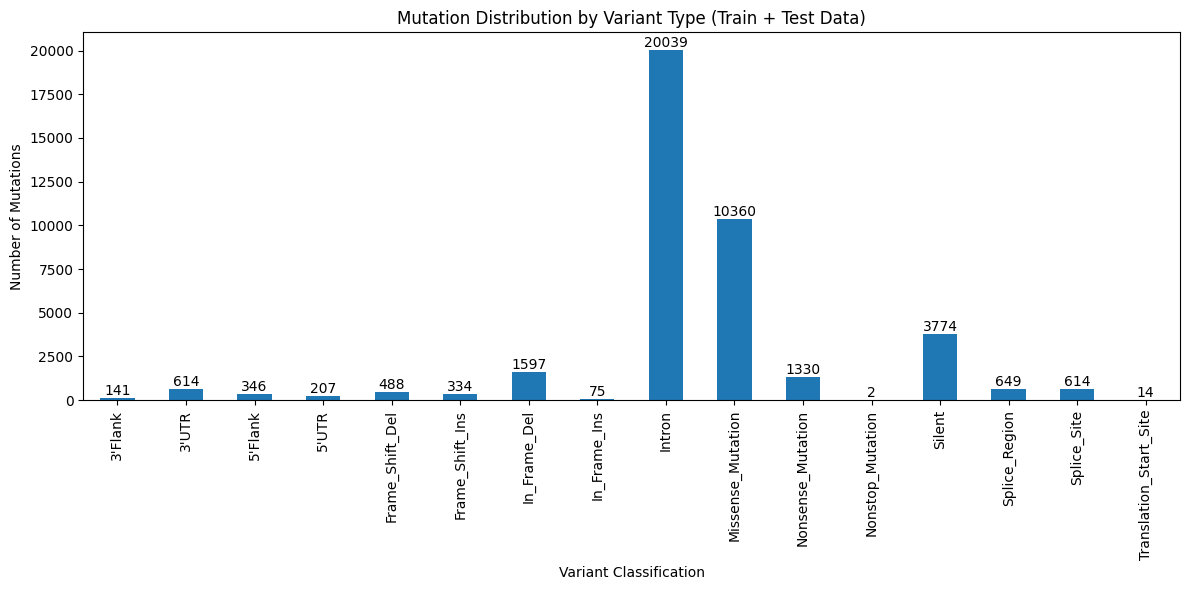

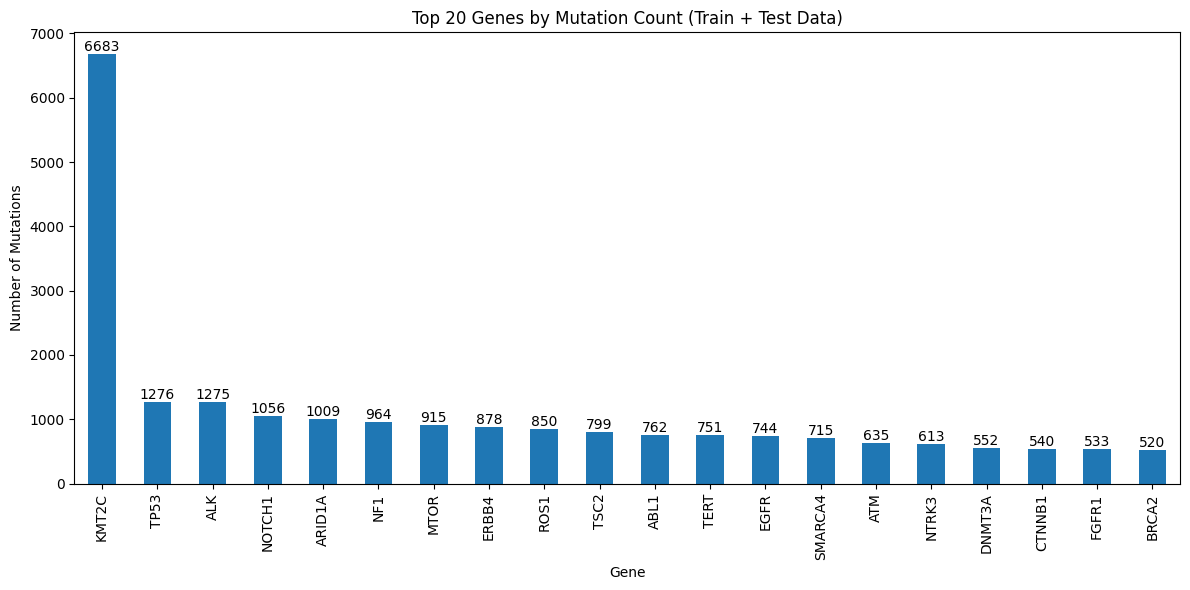

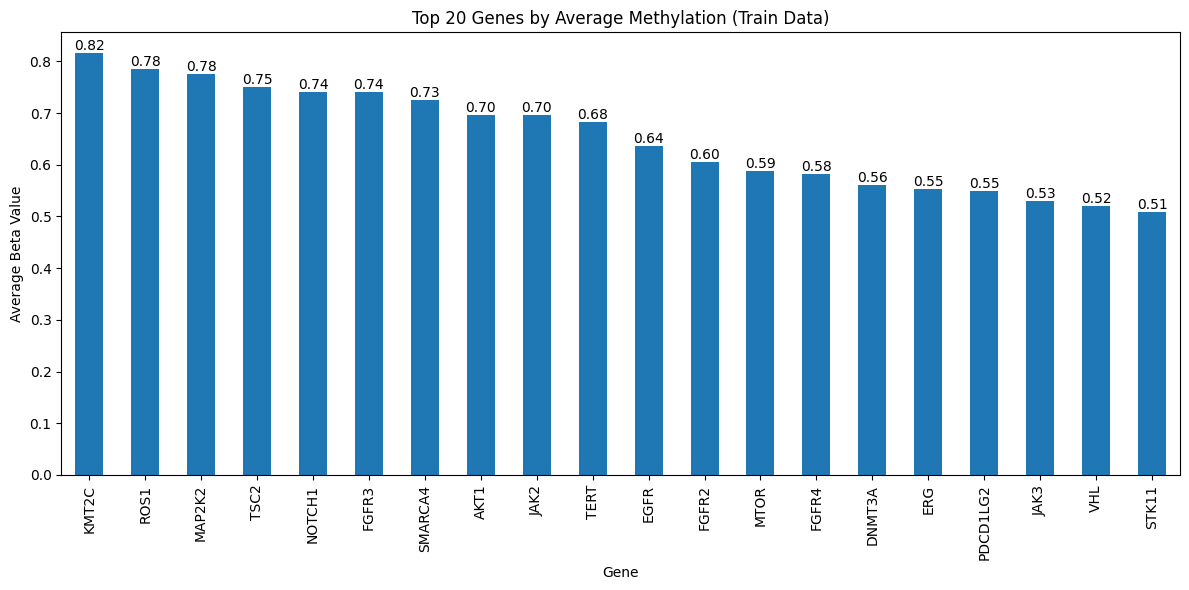

In [7]:
print("Creating visualizations for Task 2...")
# Mutation Distribution by Variant Type (Train + Test)
all_muts = pd.concat([train_muts, test_muts], ignore_index=True)
grouped_data = all_muts.groupby('Variant_Classification').size()
plt.figure(figsize=(12, 6))
bars = grouped_data.plot(kind='bar')
plt.xlabel('Variant Classification')
plt.ylabel('Number of Mutations')
plt.title('Mutation Distribution by Variant Type (Train + Test Data)')
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
             ha='center', va='bottom')
plt.tight_layout()
plt.savefig('out/mutation_distribution_by_variant.png', dpi=300)
plt.show('mutation_distribution_by_variant.png')
plt.close()

# Top 20 Genes by Mutation Count (Train + Test)
gene_totals = all_muts.groupby('Gene_name').size().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
bars = gene_totals.plot(kind='bar')
plt.xlabel('Gene')
plt.ylabel('Number of Mutations')
plt.title('Top 20 Genes by Mutation Count (Train + Test Data)')
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
             ha='center', va='bottom')
plt.tight_layout()
plt.savefig('out/mutation_distribution_by_gene.png', dpi=300)
plt.show('mutation_distribution_by_gene.png')
plt.close()

# Methylation Distribution by Gene (Train Only)
meth_avg = train_meth.groupby('matching_genes')['beta_val'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
bars = meth_avg.plot(kind='bar')
plt.xlabel('Gene')
plt.ylabel('Average Beta Value')
plt.title('Top 20 Genes by Average Methylation (Train Data)')
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}',
             ha='center', va='bottom')
plt.tight_layout()
plt.savefig('out/methylation_distribution_by_gene.png', dpi=300)
plt.show('methylation_distribution_by_gene.png')
plt.close()

# Phase 5: Model Training and Evaluation
Trains classifiers using:
- Feature selection (VarianceThreshold, SelectKBest)
- RandomForest and XGBoost with GridSearchCV
- Validation on 20% stratified split
- Comparison with baseline metrics

Training Task 2 classifier...
RandomForest - Validation error: 0.4286
F1-Score: 0.5657
Precision: 0.5730
Recall: 0.5714


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:14:35] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


XGBoost - Validation error: 0.4224
F1-Score: 0.5755
Precision: 0.5779
Recall: 0.5776

Model Performance Comparison:
Expected baseline (Task 1): F1-Score: 0.658, Precision: 0.676, Recall: 0.664

Actual performance (Task 2):
       Model  F1-Score  Precision   Recall  Error Rate
RandomForest  0.565719   0.573011 0.571429    0.428571
     XGBoost  0.575508   0.577865 0.577640    0.422360
Generating confusion matrix...


<Figure size 800x600 with 0 Axes>

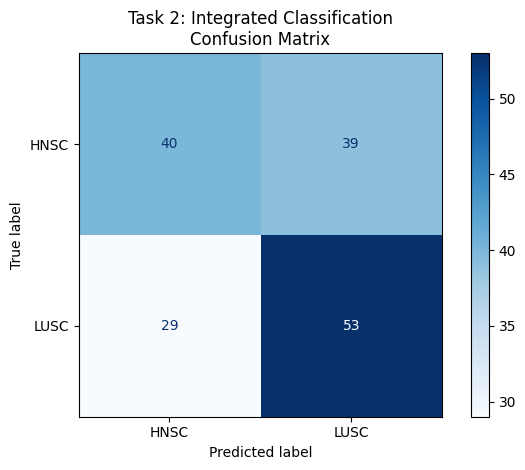

Task 2 completed. Outputs saved to 'out' directory.


In [8]:
print("Training Task 2 classifier...")
y_train = train_feats['Label'].astype(int) - 1
X_train_combined = train_combined.drop(columns=['case_id']).fillna(0)
X_test_combined = test_combined.drop(columns=['case_id']).fillna(0)
X_test_combined = X_test_combined.reindex(columns=X_train_combined.columns, fill_value=0)

# Feature selection
variance_threshold = VarianceThreshold(threshold=0)
X_train_combined_var = variance_threshold.fit_transform(X_train_combined)
X_test_combined_var = variance_threshold.transform(X_test_combined)
selector = SelectKBest(score_func=f_classif, k=100)
X_train_combined_selected = selector.fit_transform(X_train_combined_var, y_train)
X_test_combined_selected = selector.transform(X_test_combined_var)

# Split data
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_combined_selected, y_train, test_size=0.2, stratify=y_train, random_state=42)

# Classifiers
classifiers = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(tree_method='hist', device='cuda', random_state=42)
}

best_classifier = None
best_score = 0
best_name = None
metrics_comparison = []

# Train and evaluate
for name, classifier in classifiers.items():
    param_grid = {
        'RandomForest': {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5]},
        'XGBoost': {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.3], 'n_estimators': [100, 200, 300]}
    }[name]
    grid_search = GridSearchCV(classifier, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train_split, y_train_split)
    y_val_pred = grid_search.predict(X_val)
    error = (y_val_pred != y_val).mean()
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    precision = precision_score(y_val, y_val_pred, average='weighted')
    recall = recall_score(y_val, y_val_pred, average='weighted')
    metrics_comparison.append({'Model': name, 'F1-Score': f1, 'Precision': precision, 'Recall': recall, 'Error Rate': error})
    print(f"{name} - Validation error: {error:.4f}\nF1-Score: {f1:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}")
    if f1 > best_score:
        best_score = f1
        best_classifier = grid_search.best_estimator_
        best_name = name

# Display metrics
metrics_df = pd.DataFrame(metrics_comparison)
print("\nModel Performance Comparison:")
print("Expected baseline (Task 1): F1-Score: 0.658, Precision: 0.676, Recall: 0.664")
print("\nActual performance (Task 2):")
print(metrics_df.to_string(index=False))

# Retrain best model
if best_name == 'XGBoost':
    dtrain = xgb.DMatrix(X_train_combined_selected, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test_combined_selected)
    params = best_classifier.get_xgb_params()
    params.update({'tree_method': 'hist', 'device': 'cuda'})
    xgb_model = xgb.train(
        params, dtrain, num_boost_round=1000, evals=[(dval, "validation")],
        early_stopping_rounds=10, verbose_eval=False)
    y_test_pred = xgb_model.predict(dtest)
    y_test_pred = (y_test_pred > 0.5).astype(int) + 1
else:
    best_classifier.fit(X_train_combined_selected, y_train)
    y_test_pred = best_classifier.predict(X_test_combined_selected) + 1

# Save predictions
pd.DataFrame({'id_case': test_combined['case_id'], 'label_predict': y_test_pred}).to_csv('out/task2_predictions.csv', index=False)

# Confusion matrix
print("Generating confusion matrix...")
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(y_val, best_classifier.predict(X_val), labels=[0, 1], display_labels=['HNSC', 'LUSC'], cmap='Blues')
plt.title('Task 2: Integrated Classification\nConfusion Matrix')
plt.tight_layout()
plt.savefig('out/confusion_matrix_task2.png', dpi=300)
plt.show('confusion_matrix_task2.png')
plt.close()

print("Task 2 completed. Outputs saved to 'out' directory.")